# Reto: patrones temporales en un sistema de bicicletas públicas

**Fecha de entrega:** Martes 22 de septiembre a la media noche

En clase descubrimos algo muy interesante con el viento: **no existe "un" viento típico** — el
viento de las 6pm en enero no se parece en nada al de las 3am en julio. La única forma de
entenderlo de verdad fue "romper" el promedio general en pedazos más pequeños (por hora, por
mes) y comparar.

Este reto te pide hacer exactamente ese mismo ejercicio mental, pero con un fenómeno distinto
y muy cotidiano: **cuántos viajes se hacen por hora en el sistema de bicicletas compartidas de
una ciudad** (como los sistemas de "bicicletas públicas" que existen en muchas ciudades).

Este reto es más sencillo que el anterior — **no necesitas ajustar ninguna distribución de
probabilidad**. Solo vas a usar `groupby`, gráficas de barras, boxplots y, si quieres, un
heatmap — las mismas herramientas que ya usamos en clase para explorar patrones.

## Lo que queremos que descubras (sin que te lo digamos directamente)

- ¿A qué horas del día se usan más las bicicletas? ¿Por qué crees que pasa eso?
- ¿Se usan igual entre semana que el fin de semana?
- ¿El patrón **por hora** es el mismo entre semana que el fin de semana, o cambia por
  completo?
- ¿Hay meses con más o menos uso?

## Checklist de entrega

- [ ] Tarea 1: estadística descriptiva básica del número de viajes por hora
- [ ] Tarea 2: patrón según la hora del día (gráfica + interpretación)
- [ ] Tarea 3: patrón según el día de la semana (gráfica + interpretación)
- [ ] Tarea 4: el patrón por hora, comparado entre semana vs. fin de semana (esta es la parte
      más importante del reto)
- [ ] Tarea 5 (bonus): patrón según el mes
- [ ] Conclusión final escrita en una celda de markdown (mínimo 3-5 frases)

**Recomendación:** no borres la sección 2 (ejemplo resuelto) — te sirve como plantilla del
estilo de código y gráficas que esperamos ver en tus tareas.


## 1. Código base: los datos (ya resuelto, no lo modifiques)

Vamos a trabajar con datos **inventados** (pero con un comportamiento realista) de un sistema
de bicicletas compartidas: cuántos viajes se iniciaron, hora por hora, durante 2 años.

No necesitas entender cada línea de esta celda — lo importante es el resultado: un DataFrame
`df` con columnas `Year`, `Month`, `Day`, `Hour`, `DayOfWeek` (0 = lunes, 6 = domingo),
`DiaSemana` (el nombre del día en español) y `EsFinDeSemana` (`True`/`False`), además de la
columna que vamos a analizar: `Viajes` (número de viajes iniciados en esa hora).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(3)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "font.size": 11})

fechas = pd.date_range(start="2023-01-01 00:00", end="2024-12-31 23:00", freq="1h")

nombres_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
dia_semana_num = fechas.dayofweek  # 0 = lunes ... 6 = domingo
es_fin_de_semana = dia_semana_num >= 5

# Entre semana: dos picos (hora de entrada y salida del trabajo/universidad)
patron_entre_semana = (
    480 * np.exp(-0.5 * ((fechas.hour - 7.5) / 1.3) ** 2)
    + 520 * np.exp(-0.5 * ((fechas.hour - 17.5) / 1.3) ** 2)
    + 25
)

# Fin de semana: un solo pico, más amplio, a mitad del día (paseos, no desplazamientos)
patron_fin_de_semana = (
    260 * np.exp(-0.5 * ((fechas.hour - 13) / 3.2) ** 2)
    + 15
)

# Pequeña variación según el mes (algunos meses llueve más y se usa menos la bicicleta)
factor_mes = np.array([1.10, 1.05, 1.00, 0.85, 0.80, 0.95, 1.00, 1.00, 0.95, 0.80, 0.85, 1.05])
factor_mensual = factor_mes[fechas.month - 1]

viajes_esperados = np.where(es_fin_de_semana, patron_fin_de_semana, patron_entre_semana) * factor_mensual
viajes_esperados = np.clip(viajes_esperados, 0, None)

viajes = np.random.poisson(lam=viajes_esperados)

df = pd.DataFrame({
    "Year": fechas.year,
    "Month": fechas.month,
    "Day": fechas.day,
    "Hour": fechas.hour,
    "DayOfWeek": dia_semana_num,
    "DiaSemana": [nombres_dias[d] for d in dia_semana_num],
    "EsFinDeSemana": es_fin_de_semana,
    "Viajes": viajes,
}, index=fechas)

col = "Viajes"

print(df.shape)
print(df.head(26).to_string())


(17544, 8)
                     Year  Month  Day  Hour  DayOfWeek DiaSemana  EsFinDeSemana  Viajes
2023-01-01 00:00:00  2023      1    1     0          6   Domingo           True      17
2023-01-01 01:00:00  2023      1    1     1          6   Domingo           True      14
2023-01-01 02:00:00  2023      1    1     2          6   Domingo           True      12
2023-01-01 03:00:00  2023      1    1     3          6   Domingo           True       9
2023-01-01 04:00:00  2023      1    1     4          6   Domingo           True      24
2023-01-01 05:00:00  2023      1    1     5          6   Domingo           True      32
2023-01-01 06:00:00  2023      1    1     6          6   Domingo           True      38
2023-01-01 07:00:00  2023      1    1     7          6   Domingo           True      60
2023-01-01 08:00:00  2023      1    1     8          6   Domingo           True      99
2023-01-01 09:00:00  2023      1    1     9          6   Domingo           True     149
2023-01-01 10:00:00  

## 2. Ejemplo resuelto: una semana completa

Antes de empezar tus tareas, mira este ejemplo resuelto: grafiquemos los viajes hora por hora
durante una semana completa, para confirmar que los datos tienen sentido y "sentir" el patrón
antes de calcular nada.

Este es el nivel de detalle y de comentarios que esperamos ver en tus propias celdas.


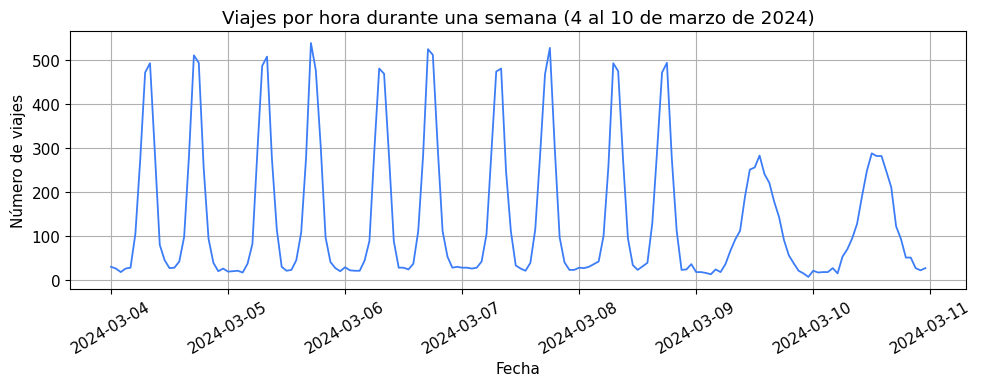

In [2]:
# Tomamos una semana como ejemplo y graficamos sus 168 horas (24 x 7)
una_semana = df.loc["2024-03-04":"2024-03-10"]  # lunes 4 a domingo 10 de marzo de 2024

plt.plot(una_semana.index, una_semana["Viajes"], color="#3C7DF7", linewidth=1.3)
plt.title("Viajes por hora durante una semana (4 al 10 de marzo de 2024)")
plt.xlabel("Fecha")
plt.ylabel("Número de viajes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Ya se alcanza a notar algo interesante a simple vista: los primeros 5 días (lunes a
viernes) tienen una forma distinta a los últimos 2 (sábado y domingo). A partir de aquí, el
reto es tuyo: confirma esto con números y gráficas más precisas.


## 3. Tarea 1 — Estadística descriptiva básica

Calcula, para **toda la columna `Viajes`** (con los 2 años de datos juntos):

- Media, mediana y desviación estándar.
- El valor mínimo y el máximo.

Luego, grafica el histograma completo de `Viajes`, marcando la media con una línea vertical.

💡 **Pista:** vas a notar que el histograma tiene una forma un poco rara (muchas horas con
pocos viajes, pocas horas con muchísimos viajes). Coméntalo en una celda de markdown: ¿por qué
crees que pasa eso? (Piensa en cuántas horas del día son de "hora pico" comparadas con el
resto.)


In [3]:
# TODO: calcula media, mediana, desviación estándar, mínimo y máximo de df[col]
# media = ...
# mediana = ...
# desv_std = ...
# minimo, maximo = ...

# TODO: imprime los resultados con print(), usando f-strings como en clase

# TODO: grafica el histograma de df[col] con plt.hist(), marcando la media con plt.axvline()


*(Escribe aquí tu comentario sobre la forma del histograma.)*


## 4. Tarea 2 — Patrón según la hora del día

Calcula el promedio de `Viajes` **agrupado por hora** (`groupby("Hour")`) usando **todos los
datos juntos** (sin separar entre semana y fin de semana todavía — eso lo harás en la Tarea 4).

Grafica el resultado en un gráfico de barras.


In [4]:
# TODO: viajes_por_hora = df.groupby(...)[col].mean()

# TODO: grafica viajes_por_hora con plt.bar()


*(Escribe aquí: ¿a qué horas hay más viajes? ¿Coincide con algo que tenga sentido para
ti en la vida real?)*


## 5. Tarea 3 — Patrón según el día de la semana

Calcula el promedio de `Viajes` **agrupado por día de la semana** (puedes usar la columna
`DiaSemana` o `DayOfWeek`) y grafícalo en un gráfico de barras.

💡 **Pista:** si agrupas por `DiaSemana` (los nombres en español), el orden de las barras puede
salir alfabético en vez de lunes-a-domingo. Si quieres que salgan en el orden correcto, agrupa
por `DayOfWeek` (que ya viene numerado 0=lunes a 6=domingo) y usa la lista `nombres_dias` de la
sección 1 para poner las etiquetas del eje x.


In [5]:
# TODO: viajes_por_dia = df.groupby(...)[col].mean()

# TODO: grafica viajes_por_dia con plt.bar()


*(Escribe aquí: ¿qué días tienen más viajes? ¿Se nota una diferencia clara entre semana
y fin de semana?)*


## 6. Tarea 4 — El patrón por hora, ¿es el mismo todos los días?

Esta es la parte central del reto — la misma idea que descubrimos con el viento (mes Y hora al
mismo tiempo), pero aquí con día de la semana Y hora al mismo tiempo.

1. Separa el DataFrame en dos partes usando la columna `EsFinDeSemana`: una con los datos
   **entre semana** (`EsFinDeSemana == False`) y otra con los datos de **fin de semana**
   (`EsFinDeSemana == True`).
2. Para cada una, calcula el promedio de `Viajes` por hora (igual que en la Tarea 2, pero
   ahora por separado).
3. Grafica **las dos curvas juntas en la misma gráfica** (una línea para entre semana, otra
   para fin de semana), para poder compararlas directamente.

💡 **Pista:** usa `plt.plot()` dos veces sobre los mismos ejes (antes de `plt.show()`), con un
`label` distinto para cada línea, y `plt.legend()` al final para poder identificarlas.


In [6]:
# TODO: separa el df en df_entre_semana y df_fin_de_semana usando la columna EsFinDeSemana

# TODO: calcula el promedio de Viajes por hora para cada uno de los dos grupos

# TODO: grafica ambas curvas juntas (plt.plot() dos veces + plt.legend())


*(Escribe aquí: ¿el patrón por hora es el mismo entre semana y fin de semana, o cambia
por completo? ¿Qué explicación le das? Esta observación es exactamente la misma clase de
hallazgo que hicimos con el viento —solo que ahora la condición no es el mes, sino el tipo de
día.)*


## 7. Tarea 5 (bonus, opcional) — Patrón según el mes

Calcula el promedio de `Viajes` agrupado por mes y grafícalo. ¿Hay meses con más o menos uso?

Si quieres ir más allá: construye un heatmap (mapa de calor) de mes × hora, igual al que
hicimos en clase con `df.pivot_table(...)` y `plt.imshow(...)`, para ver los dos patrones (el
mensual y el horario) al mismo tiempo.


In [7]:
# TODO (bonus): viajes_por_mes = df.groupby(...)[col].mean()
# TODO (bonus): grafica viajes_por_mes con plt.bar()

# TODO (bonus, extra): heatmap mes x hora con pivot_table() + plt.imshow()


## 8. Conclusión (obligatoria)

Escribe aquí, en tus propias palabras, entre 3 y 5 frases respondiendo:

- ¿Por qué "el promedio general de viajes por hora" (sin separar nada) es una estadística
  engañosa para este fenómeno?
- ¿Qué tuviste que "condicionar" (separar) para entender realmente el comportamiento del
  sistema de bicicletas?
- ¿En qué se parece este hallazgo al que hicimos en clase con el viento (hora + mes)?

*(Escribe tu respuesta aquí, reemplazando este texto.)*
